# Метод опорных векторов — расширенные эксперименты

> Выполнение заданий 1, 2 из лабораторной работы ML3.2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC
from sklearn import metrics

def plot_decision_regions(X, y, model, ax=None, title="Граница принятия решения"):
    if ax is None:
        ax = plt.gca()
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               linewidth=6, facecolors='none', edgecolors='green', s=200, label='Опорные векторы')
    ax.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=80, label='Класс 0')
    ax.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=80, label='Класс 1')
    x0_range = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    x1_range = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)
    X0g, X1g = np.meshgrid(x0_range, x1_range)
    Z = model.decision_function(np.c_[X0g.ravel(), X1g.ravel()]).reshape(X0g.shape)
    ax.contourf(X0g, X1g, Z, levels=[-3, -1, 1, 3],
                colors=['#FFAAAA', '#FFDDDD', '#DDDDFF', '#AAAAFF'], alpha=0.5)
    ax.contour(X0g, X1g, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X0'); ax.set_ylabel('X1')
    ax.legend(fontsize=8)

## Задание 1, часть А: Влияние параметра C

Параметр **C** управляет балансом между шириной зазора и числом ошибок классификации:
- **Малый C** → широкая полоса зазора, модель допускает больше нарушений (мягкий зазор)  
- **Большой C** → узкая полоса, модель стремится классифицировать все точки верно (жёсткий зазор)

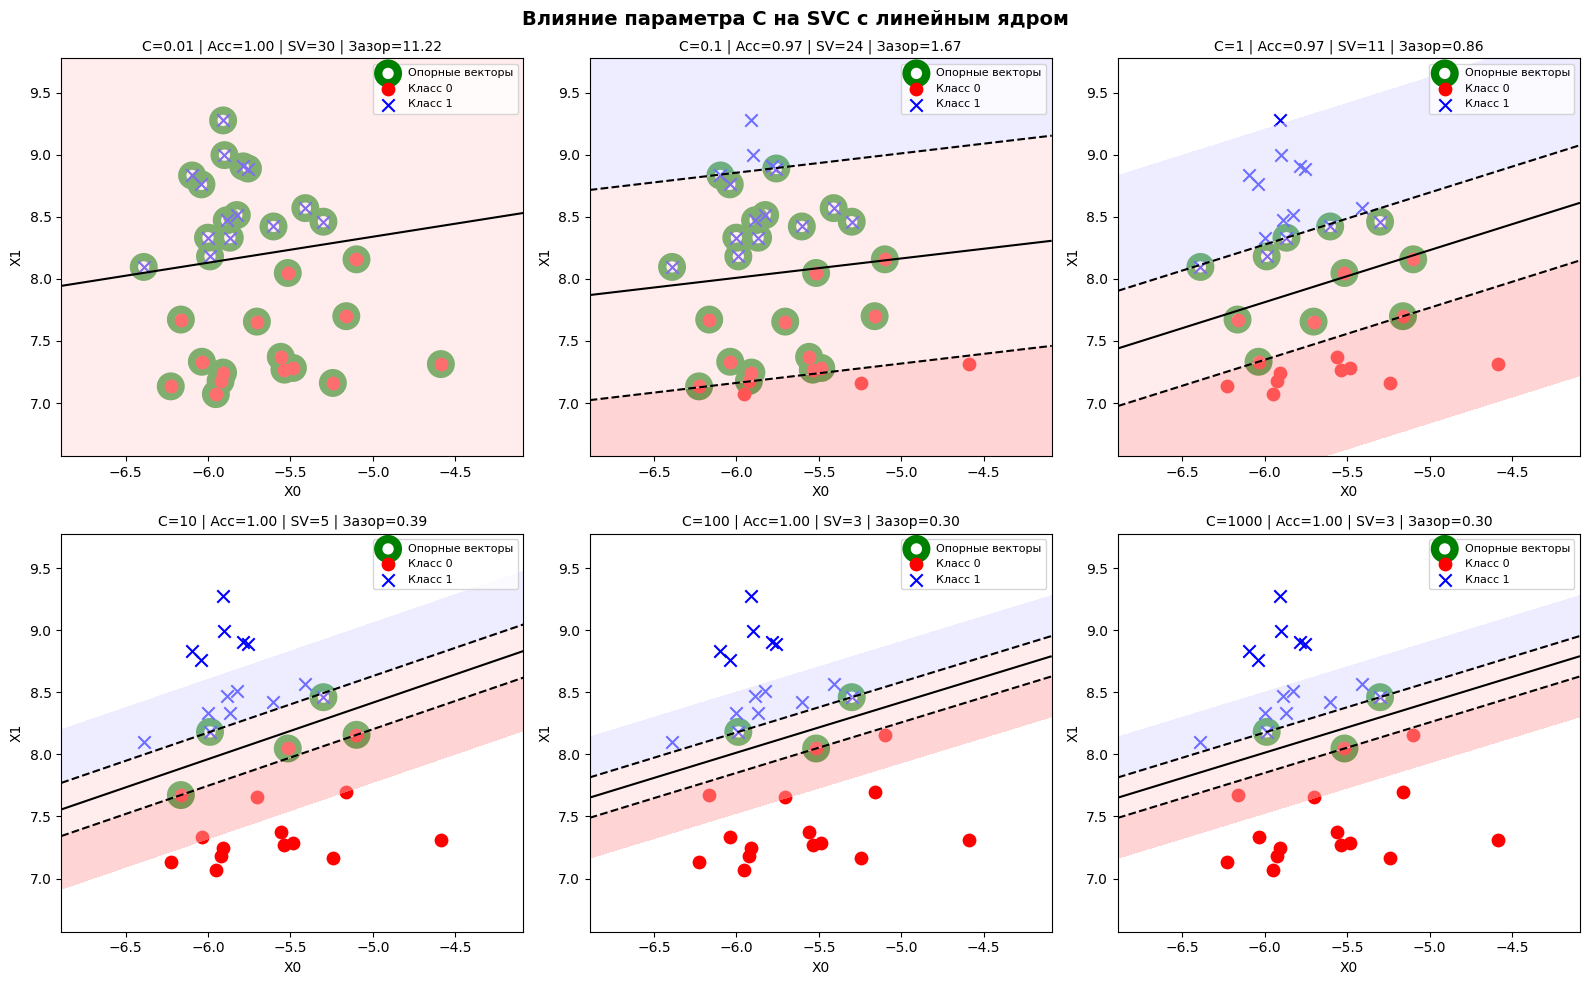

In [2]:
X1, y1 = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

C_values = [0.01, 0.1, 1, 10, 100, 1000]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Влияние параметра C на SVC с линейным ядром", fontsize=14, fontweight='bold')

for ax, C in zip(axes.ravel(), C_values):
    model = SVC(kernel='linear', C=C).fit(X1, y1)
    y_pred = model.predict(X1)
    acc = metrics.accuracy_score(y1, y_pred)
    n_sv = model.n_support_.sum()
    margin = 2 / np.linalg.norm(model.coef_)
    plot_decision_regions(X1, y1, model, ax=ax,
                          title=f"C={C} | Acc={acc:.2f} | SV={n_sv} | Зазор={margin:.2f}")

plt.tight_layout()
plt.show()

In [3]:
# Сводная таблица: C vs точность vs количество SV vs ширина зазора
print(f"{'C':>8} | {'Accuracy':>10} | {'Опорных векторов':>18} | {'Ширина зазора'}")
print("-" * 58)
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    model = SVC(kernel='linear', C=C).fit(X1, y1)
    y_pred = model.predict(X1)
    acc = metrics.accuracy_score(y1, y_pred)
    margin = 2 / np.linalg.norm(model.coef_)
    print(f"{C:>8} | {acc:>10.4f} | {model.n_support_.sum():>18} | {margin:.4f}")

       C |   Accuracy |   Опорных векторов | Ширина зазора
----------------------------------------------------------
    0.01 |     1.0000 |                 30 | 11.2200
     0.1 |     0.9667 |                 24 | 1.6725
       1 |     0.9667 |                 11 | 0.8559
      10 |     1.0000 |                  5 | 0.3895
     100 |     1.0000 |                  3 | 0.3014
    1000 |     1.0000 |                  3 | 0.3014


### Вывод по параметру C

| C | Поведение модели |
|---|---|
| **Малый (0.01–0.1)** | Широкий зазор, много опорных векторов, допускаются ошибки классификации |
| **Средний (1–10)** | Баланс между шириной зазора и точностью |
| **Большой (100–1000)** | Узкий зазор, мало опорных векторов, жёсткое разделение |

**При очень малом C** модель игнорирует отдельные выбросы и строит более «простую» границу — это регуляризация.  
**При очень большом C** модель близка к жёсткому зазору, может переобучиться на выбросах.

## Задание 1, часть Б: Предсказание при перемещении точки

Проверим, как меняется предсказание при движении точки через границу и через полосу зазора.

Функция `decision_function` возвращает **знаковое расстояние до гиперплоскости**:
- `df > 0` → класс 1
- `df < 0` → класс 0
- `-1 < df < 1` → точка **внутри полосы зазора**

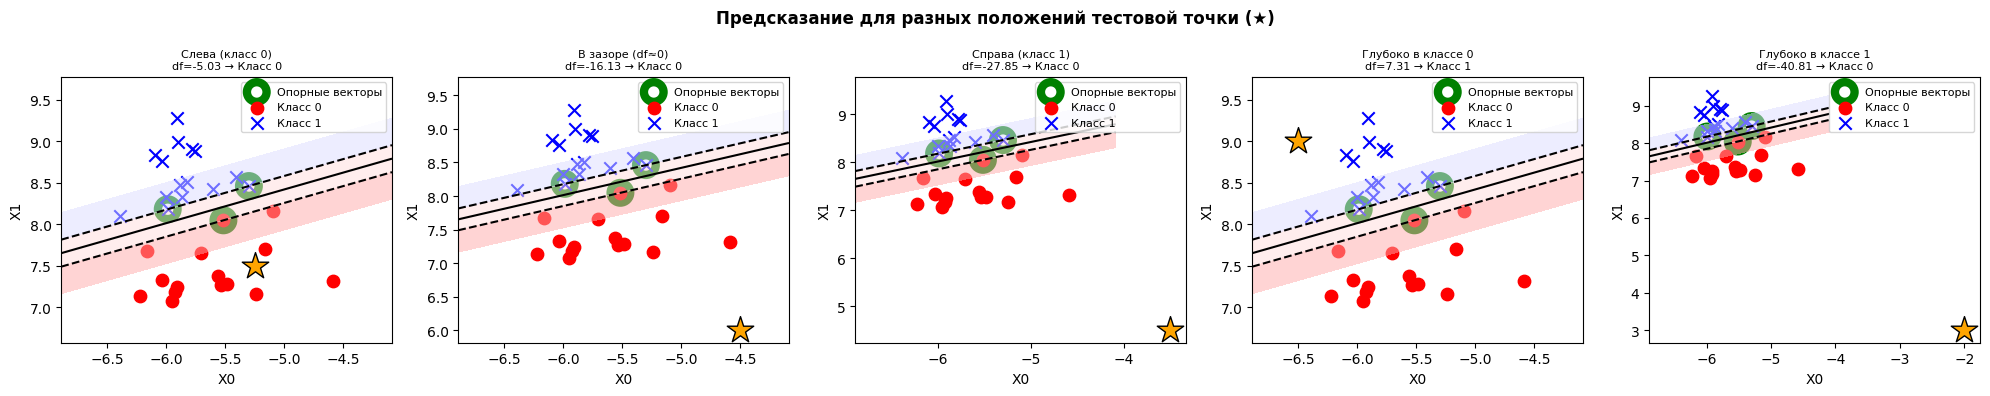

Результаты decision_function и predict:
  Слева (класс 0)               : df= -5.031, класс=0
  В зазоре (df≈0)               : df=-16.126, класс=0
  Справа (класс 1)              : df=-27.845, класс=0
  Глубоко в классе 0            : df= +7.313, класс=1
  Глубоко в классе 1            : df=-40.814, класс=0


In [4]:
svm_c100 = SVC(kernel='linear', C=100).fit(X1, y1)

test_points = {
    "Слева (класс 0)":          [[-5.25, 7.5]],
    "В зазоре (df≈0)":          [[-4.5, 6.0]],
    "Справа (класс 1)":         [[-3.5, 4.5]],
    "Глубоко в классе 0":       [[-6.5, 9.0]],
    "Глубоко в классе 1":       [[-2.0, 3.0]],
}

fig, axes = plt.subplots(1, len(test_points), figsize=(20, 4))
fig.suptitle("Предсказание для разных положений тестовой точки (★)", fontsize=12, fontweight='bold')

for ax, (label, point) in zip(axes, test_points.items()):
    plot_decision_regions(X1, y1, svm_c100, ax=ax)
    df_val = svm_c100.decision_function(point)[0]
    pred = svm_c100.predict(point)[0]
    ax.scatter(point[0][0], point[0][1], marker='*', s=400, color='orange', zorder=5,
               edgecolors='black', linewidth=1)
    zone = "в зазоре!" if abs(df_val) < 1 else f"Класс {pred}"
    ax.set_title(f"{label}\ndf={df_val:.2f} → {zone}", fontsize=8)

plt.tight_layout()
plt.show()

print("Результаты decision_function и predict:")
for label, point in test_points.items():
    df_val = svm_c100.decision_function(point)[0]
    pred = svm_c100.predict(point)[0]
    in_margin = " ← ВНУТРИ ЗАЗОРА" if abs(df_val) < 1 else ""
    print(f"  {label:30s}: df={df_val:+7.3f}, класс={pred}{in_margin}")

### Вывод по перемещению точки

- **По разные стороны** от границы (df=0) предсказываются **разные классы** — это и есть разделяющая гиперплоскость.
- **Внутри полосы зазора** (`|df| < 1`) точка всё равно классифицируется, но модель считает это «зоной неуверенности».
- Знак `decision_function` строго определяет класс; модуль показывает удалённость от границы — чем больше, тем увереннее предсказание.

## Задание 2: Сравнение ядер на нелинейных данных (make_circles)

Для концентрических окружностей линейная граница не подойдёт. Сравним все основные ядра.

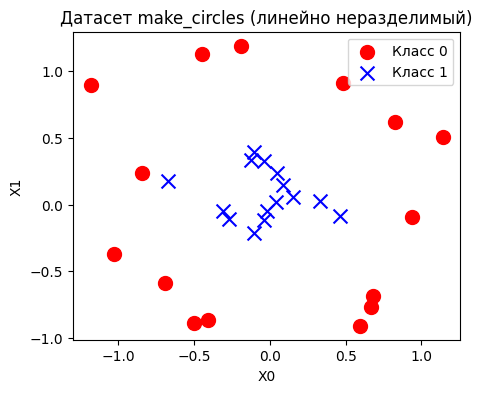

In [5]:
X2, y2 = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.figure(figsize=(5, 4))
plt.scatter(X2[:, 0][y2==0], X2[:, 1][y2==0], marker="o", c='r', s=100, label='Класс 0')
plt.scatter(X2[:, 0][y2==1], X2[:, 1][y2==1], marker="x", c='b', s=100, label='Класс 1')
plt.title("Датасет make_circles (линейно неразделимый)")
plt.xlabel('X0'); plt.ylabel('X1'); plt.legend(); plt.show()

                        Ядро |   Accuracy |   Опорных векторов
----------------------------------------------------------------
           Линейное (linear) |     0.7000 |                 30
              RBF / Гауссово |     1.0000 |                  8
           Полином. degree=3 |     0.7000 |                 29
           Полином. degree=5 |     0.8333 |                 23
                  Сигмоидное |     0.5000 |                 18


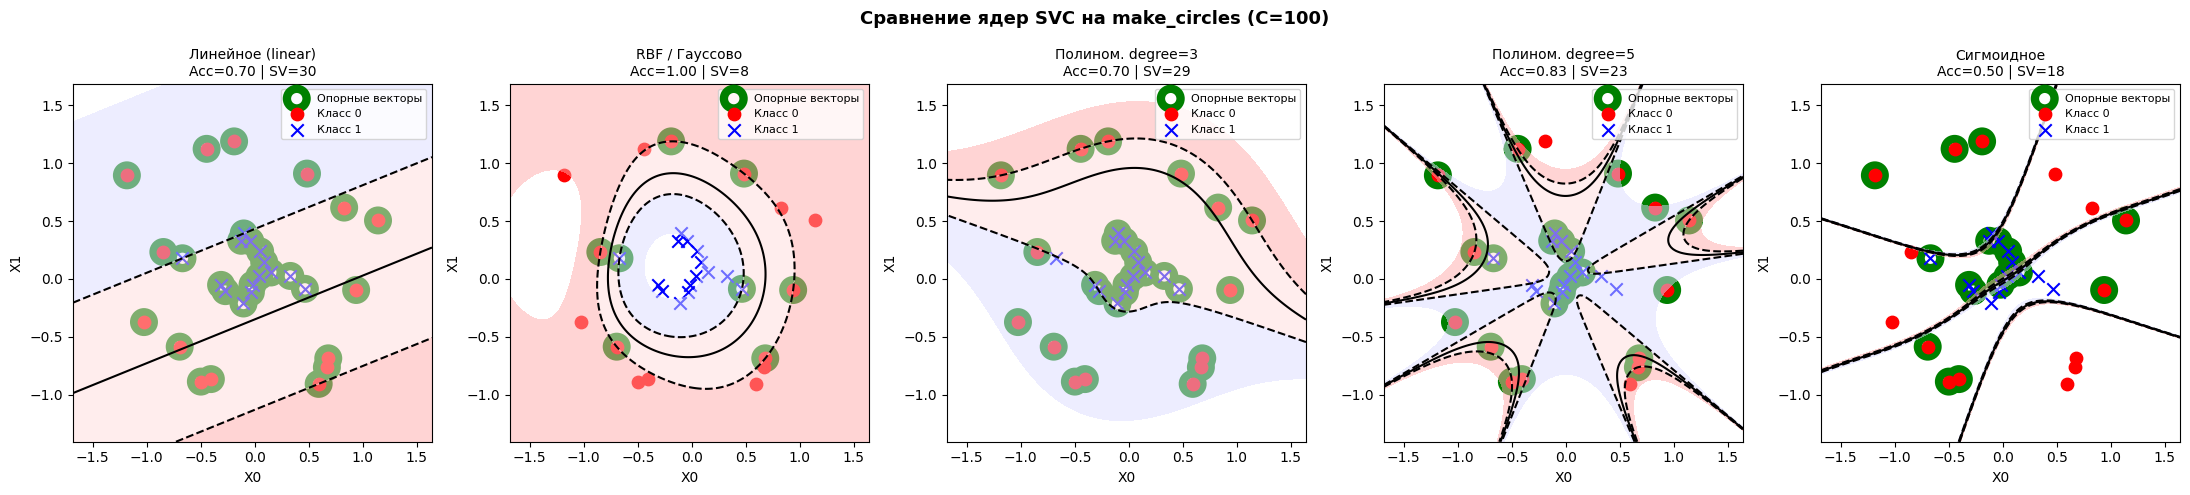

In [6]:
kernels_cfg = [
    ('linear',  {},             'Линейное (linear)'),
    ('rbf',     {'gamma':'scale'}, 'RBF / Гауссово'),
    ('poly',    {'degree':3},   'Полином. degree=3'),
    ('poly',    {'degree':5},   'Полином. degree=5'),
    ('sigmoid', {},             'Сигмоидное'),
]

fig, axes = plt.subplots(1, len(kernels_cfg), figsize=(22, 5))
fig.suptitle("Сравнение ядер SVC на make_circles (C=100)", fontsize=13, fontweight='bold')

print(f"{'Ядро':>28} | {'Accuracy':>10} | {'Опорных векторов':>18}")
print("-" * 64)

for ax, (kernel, params, label) in zip(axes, kernels_cfg):
    model = SVC(kernel=kernel, C=100, **params).fit(X2, y2)
    y_pred = model.predict(X2)
    acc = metrics.accuracy_score(y2, y_pred)
    n_sv = model.n_support_.sum()
    plot_decision_regions(X2, y2, model, ax=ax,
                          title=f"{label}\nAcc={acc:.2f} | SV={n_sv}")
    print(f"{label:>28} | {acc:>10.4f} | {n_sv:>18}")

plt.tight_layout()
plt.show()

In [7]:
# Детальные метрики
for kernel, params, label in kernels_cfg:
    model = SVC(kernel=kernel, C=100, **params).fit(X2, y2)
    y_pred = model.predict(X2)
    print(f"\n{'='*40}")
    print(f"Ядро: {label}")
    print(f"  Accuracy:          {metrics.accuracy_score(y2, y_pred):.4f}")
    print(f"  n_support_:        {model.n_support_}  (сумма: {model.n_support_.sum()})")
    print(f"  Матрица ошибок:\n  {metrics.confusion_matrix(y2, y_pred)}")


Ядро: Линейное (linear)
  Accuracy:          0.7000
  n_support_:        [15 15]  (сумма: 30)
  Матрица ошибок:
  [[ 6  9]
 [ 0 15]]

Ядро: RBF / Гауссово
  Accuracy:          1.0000
  n_support_:        [6 2]  (сумма: 8)
  Матрица ошибок:
  [[15  0]
 [ 0 15]]

Ядро: Полином. degree=3
  Accuracy:          0.7000
  n_support_:        [15 14]  (сумма: 29)
  Матрица ошибок:
  [[ 6  9]
 [ 0 15]]

Ядро: Полином. degree=5
  Accuracy:          0.8333
  n_support_:        [13 10]  (сумма: 23)
  Матрица ошибок:
  [[10  5]
 [ 0 15]]

Ядро: Сигмоидное
  Accuracy:          0.5000
  n_support_:        [ 8 10]  (сумма: 18)
  Матрица ошибок:
  [[7 8]
 [7 8]]


### Вывод по сравнению ядер

| Ядро | Accuracy | Форма границы | Комментарий |
|------|----------|---------------|-------------|
| **linear** | ~0.70 | Прямая линия | Не справляется с концентрическими классами |
| **rbf** | **1.00** | Радиальная (эллипс/окружность) | Идеально подходит для данной структуры |
| **poly(3)** | ~0.70 | Кубическая кривая | Не улавливает кольцевую структуру |
| **poly(5)** | ~0.83 | Более гибкая кривая | Лучше, но всё равно не идеально |
| **sigmoid** | ~0.50 | S-образная | Наихудший результат для этих данных |

**Вывод:** Выбор ядра принципиально важен. RBF-ядро по умолчанию является наилучшим выбором для нелинейно разделимых данных, так как оно моделирует радиально-симметричные области. Линейное и полиномиальное ядра не могут захватить кольцевую структуру данных `make_circles`.